# EDA — Titanic
Análisis exploratorio completo: carga, faltantes, outliers, distribuciones, análisis univariado y multivariado, hipótesis e insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')

carpeta_imagenes = 'images'
os.makedirs(carpeta_imagenes, exist_ok=True)

ruta_datos = 'data/titanic.csv'
print('Ruta de datos:', ruta_datos)


Ruta de datos: data/titanic.csv


## 1. Carga de datos
Se carga el archivo CSV con ruta relativa y se inspecciona estructura, tipos y primeras filas.

In [2]:
datos = pd.read_csv(ruta_datos)

print('Cantidad de filas y columnas:', datos.shape)

print(datos.dtypes)

datos.info()

datos.head()

Cantidad de filas y columnas: (891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Valores faltantes
Se cuantifica el conteo y porcentaje de faltantes por columna y se visualiza con barra y mapa de calor. Estrategia propuesta: Age → mediana (o mediana por Pclass+Sex); Cabin → eliminar la columna y crear indicador HasCabin (77 % faltante); Embarked → moda (solo 2 casos).

             Cantidad_Nulos  Porcentaje_%
Cabin                   687         77.10
Age                     177         19.87
Embarked                  2          0.22
PassengerId               0          0.00
Name                      0          0.00
Pclass                    0          0.00
Survived                  0          0.00
Sex                       0          0.00
Parch                     0          0.00
SibSp                     0          0.00
Fare                      0          0.00
Ticket                    0          0.00


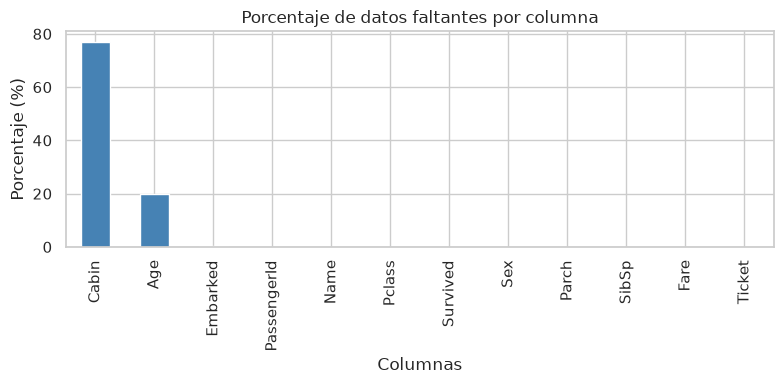

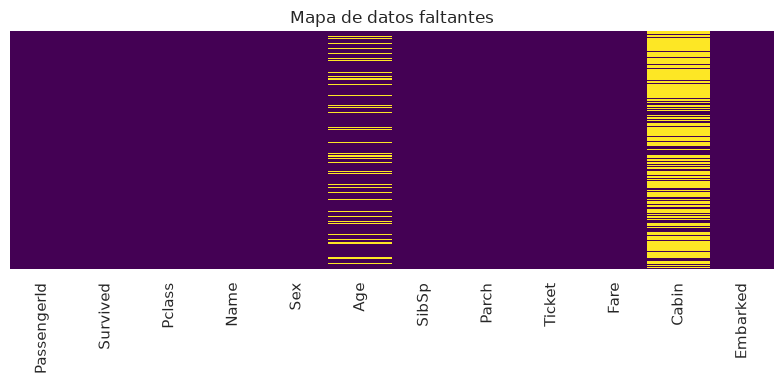

In [3]:
conteo_nulos = datos.isnull().sum()
porcentaje_nulos = (datos.isnull().sum() / len(datos)) * 100

tabla_nulos = pd.DataFrame({
    'Cantidad_Nulos': conteo_nulos,
    'Porcentaje_%': porcentaje_nulos.round(2)
}).sort_values(by='Porcentaje_%', ascending=False)

print(tabla_nulos)

plt.figure(figsize=(8, 4))
tabla_nulos['Porcentaje_%'].plot(kind='bar', color='steelblue')
plt.title('Porcentaje de datos faltantes por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'faltantes_bar.png'))
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(datos.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de datos faltantes')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'faltantes_heatmap.png'))
plt.show()

## 3. Outliers
Boxplots de Age y Fare. Detección con rango intercuartílico (IQR) y z-score (|z| > 3). Decisión: conservar los valores extremos porque corresponden a tarifas y edades reales, no a errores de captura.

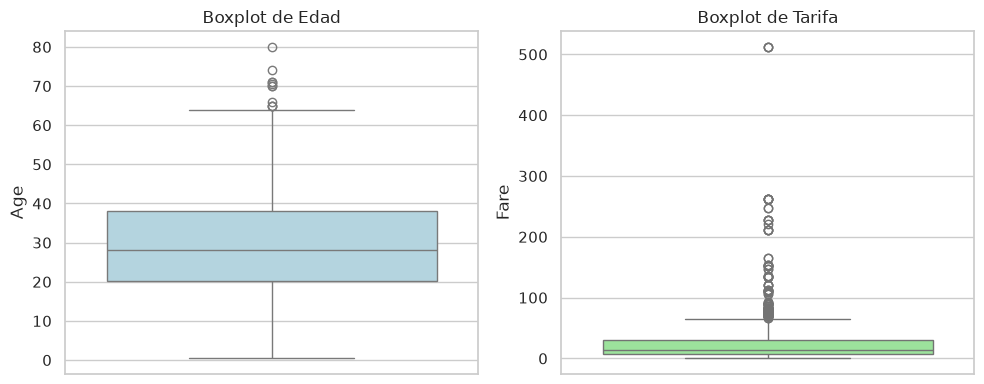

      Total_Datos  Outliers_IQR  Outliers_Z_Score
Age           714            11                 2
Fare          891           116                20
Decision: Dejamos los datos atipicos porque son pasajeros reales con edades y tarifas verdaderas.


In [4]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=datos['Age'], color='lightblue')
plt.title('Boxplot de Edad')

plt.subplot(1, 2, 2)
sns.boxplot(y=datos['Fare'], color='lightgreen')
plt.title('Boxplot de Tarifa')

plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'outliers_boxplot.png'))
plt.show()

q1_edad = datos['Age'].quantile(0.25)
q3_edad = datos['Age'].quantile(0.75)
iqr_edad = q3_edad - q1_edad
limite_bajo_edad = q1_edad - 1.5 * iqr_edad
limite_alto_edad = q3_edad + 1.5 * iqr_edad
outliers_edad = datos[(datos['Age'] < limite_bajo_edad) | (datos['Age'] > limite_alto_edad)]

q1_tarifa = datos['Fare'].quantile(0.25)
q3_tarifa = datos['Fare'].quantile(0.75)
iqr_tarifa = q3_tarifa - q1_tarifa
limite_bajo_tarifa = q1_tarifa - 1.5 * iqr_tarifa
limite_alto_tarifa = q3_tarifa + 1.5 * iqr_tarifa
outliers_tarifa = datos[(datos['Fare'] < limite_bajo_tarifa) | (datos['Fare'] > limite_alto_tarifa)]

z_edad = (datos['Age'] - datos['Age'].mean()) / datos['Age'].std()
outliers_z_edad = datos[z_edad.abs() > 3]

z_tarifa = (datos['Fare'] - datos['Fare'].mean()) / datos['Fare'].std()
outliers_z_tarifa = datos[z_tarifa.abs() > 3]

tabla_outliers = pd.DataFrame({
    'Total_Datos': [datos['Age'].count(), datos['Fare'].count()],
    'Outliers_IQR': [len(outliers_edad), len(outliers_tarifa)],
    'Outliers_Z_Score': [len(outliers_z_edad), len(outliers_z_tarifa)]
}, index=['Age', 'Fare'])

print(tabla_outliers)
print('Decision: Dejamos los datos atipicos porque son pasajeros reales con edades y tarifas verdaderas.')

## 4. Distribuciones
Histogramas con KDE de Age y Fare, cálculo de sesgo (skew). Fare presenta fuerte asimetría positiva: se sugiere transformación logarítmica para modelado posterior.

Asimetria de Edad: 0.389
Asimetria de Tarifa: 4.787


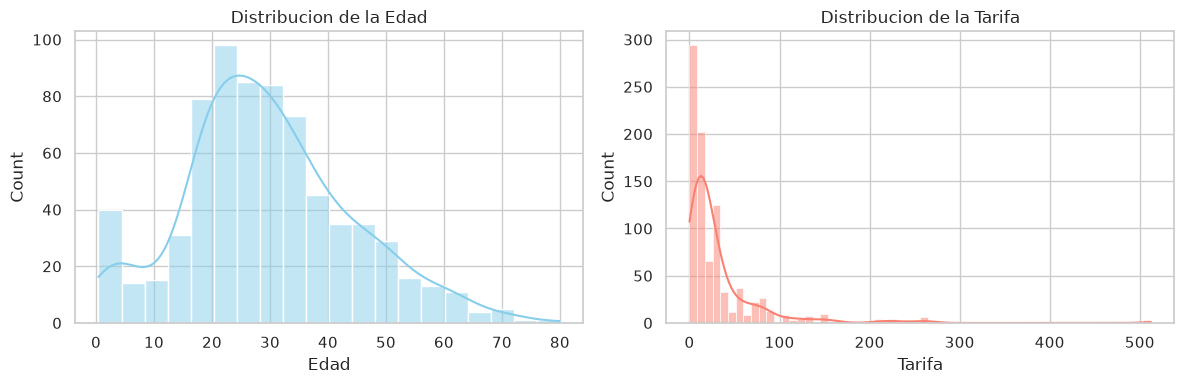

Nota: La tarifa tiene mucha asimetria hacia la derecha porque la mayoria pago poco y pocos pagaron mucho.


In [5]:
asimetria_edad = datos['Age'].skew()
asimetria_tarifa = datos['Fare'].skew()
print('Asimetria de Edad:', round(asimetria_edad, 3))
print('Asimetria de Tarifa:', round(asimetria_tarifa, 3))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(datos['Age'].dropna(), kde=True, color='skyblue')
plt.title('Distribucion de la Edad')
plt.xlabel('Edad')

plt.subplot(1, 2, 2)
sns.histplot(datos['Fare'].dropna(), kde=True, color='salmon')
plt.title('Distribucion de la Tarifa')
plt.xlabel('Tarifa')

plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'distribuciones_age_fare.png'))
plt.show()

print('Nota: La tarifa tiene mucha asimetria hacia la derecha porque la mayoria pago poco y pocos pagaron mucho.')

## 5. Análisis univariado
Estadísticos descriptivos y barras de Sex, Pclass, Embarked y Survived con porcentajes anotados.

             count unique                      top freq       mean  \
PassengerId  891.0    NaN                      NaN  NaN      446.0   
Survived     891.0    NaN                      NaN  NaN   0.383838   
Pclass       891.0    NaN                      NaN  NaN   2.308642   
Name           891    891  Braund, Mr. Owen Harris    1        NaN   
Sex            891      2                     male  577        NaN   
Age          714.0    NaN                      NaN  NaN  29.699118   
SibSp        891.0    NaN                      NaN  NaN   0.523008   
Parch        891.0    NaN                      NaN  NaN   0.381594   
Ticket         891    681                   347082    7        NaN   
Fare         891.0    NaN                      NaN  NaN  32.204208   
Cabin          204    147                       G6    4        NaN   
Embarked       889      3                        S  644        NaN   

                    std   min     25%      50%    75%       max  
PassengerId  257.353842

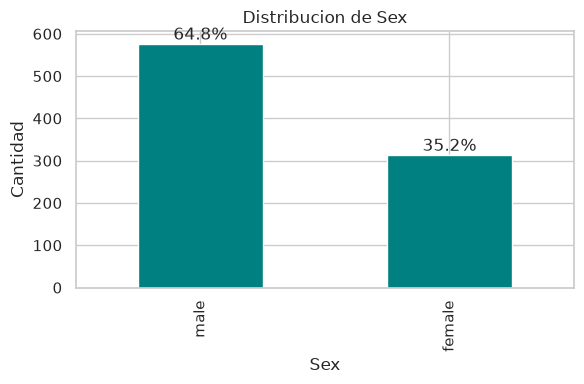

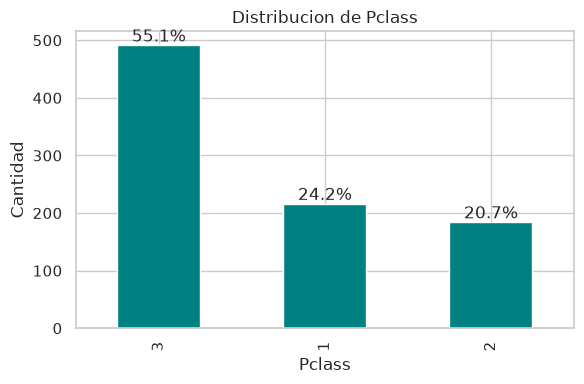

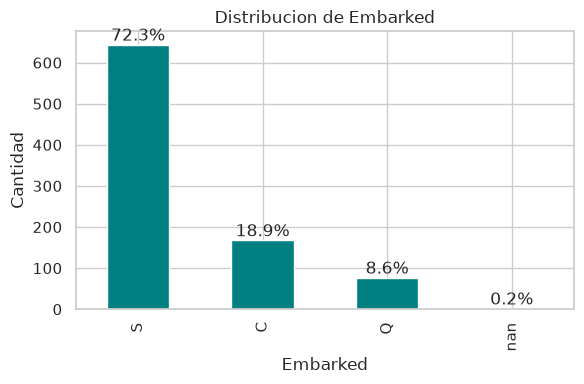

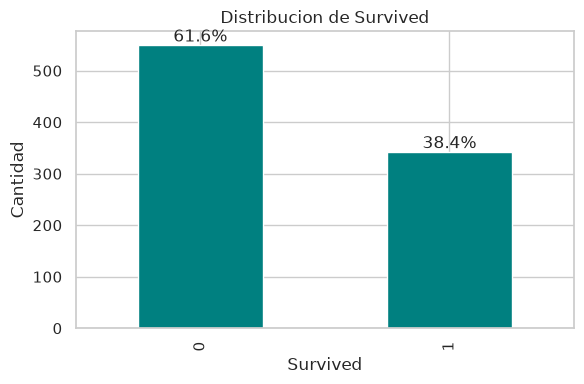

Porcentaje de supervivencia general:
Survived
0    61.6
1    38.4
Name: proportion, dtype: float64


In [6]:
print(datos.describe(include='all').T)

columnas_categoricas = ['Sex', 'Pclass', 'Embarked', 'Survived']

for columna in columnas_categoricas:
    conteo = datos[columna].value_counts(dropna=False)
    porcentaje = (datos[columna].value_counts(normalize=True, dropna=False) * 100).round(1)

    plt.figure(figsize=(6, 4))
    grafico = conteo.plot(kind='bar', color='teal')
    plt.title('Distribucion de ' + columna)
    plt.xlabel(columna)
    plt.ylabel('Cantidad')

    for i, valor in enumerate(conteo):
        pct = porcentaje.iloc[i]
        grafico.text(i, valor, f'{pct:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(os.path.join(carpeta_imagenes, f'univariado_{columna}.png'))
    plt.show()

print('Porcentaje de supervivencia general:')
print((datos['Survived'].value_counts(normalize=True) * 100).round(1))

## 6. Relaciones multivariadas
Mapa de correlación numérica, tablas cruzadas y barras agrupadas de Survived por Sex y Pclass, boxplot de Fare por Survived, histograma superpuesto de Age por Survived y dispersión Age vs Fare coloreada por Survived.

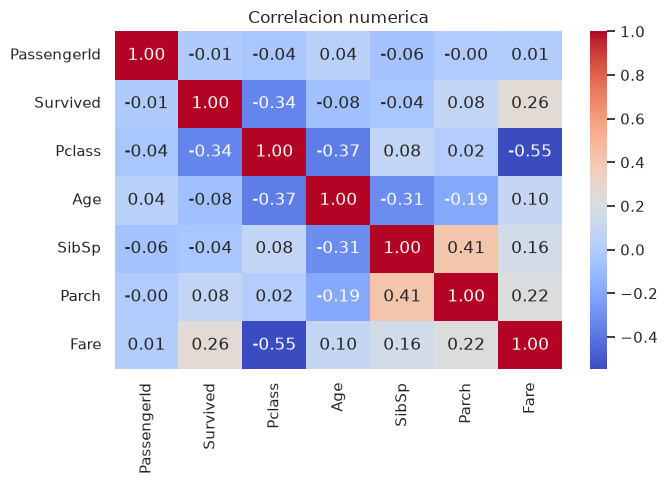

Supervivencia por Sexo (%):
 Survived     0     1
Sex                 
female    25.8  74.2
male      81.1  18.9

Supervivencia por Clase (%):
 Survived     0     1
Pclass              
1         37.0  63.0
2         52.7  47.3
3         75.8  24.2


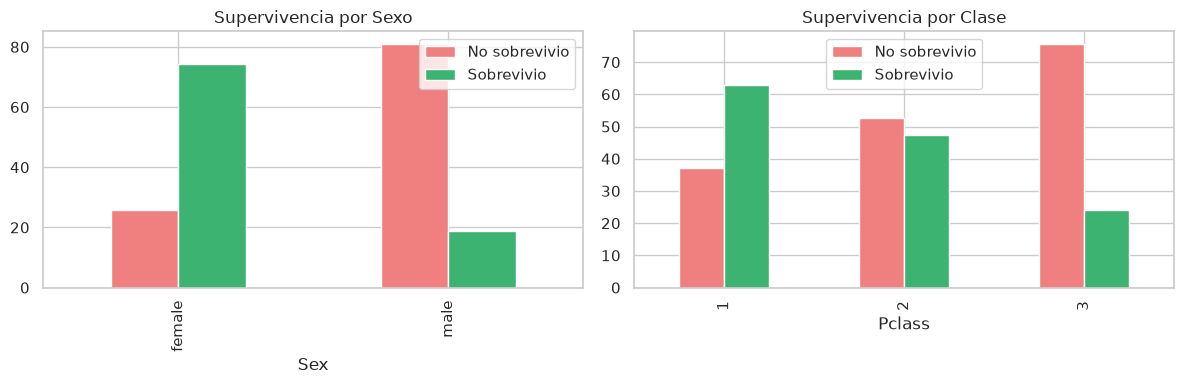

/tmp/ipykernel_225731/3944732167.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=datos, palette=['lightcoral', 'mediumseagreen'])


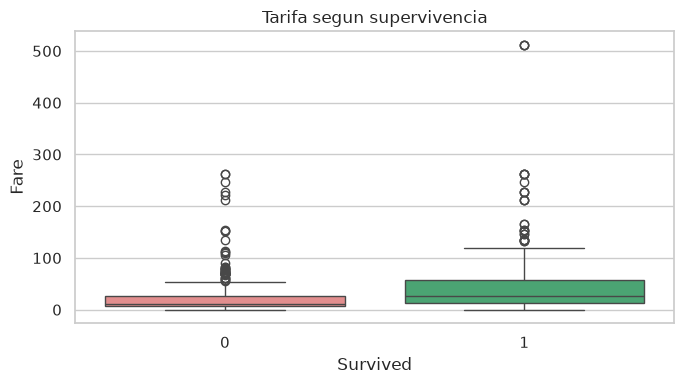

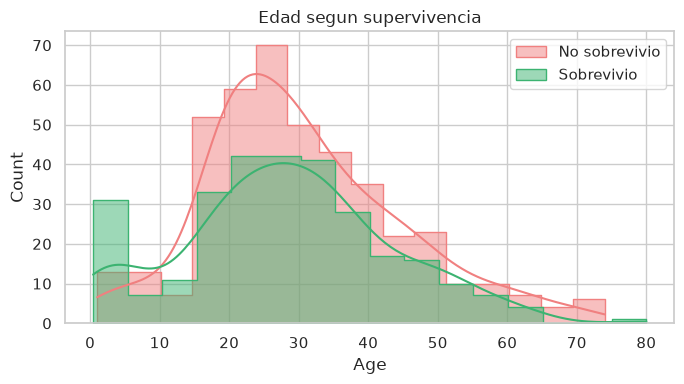

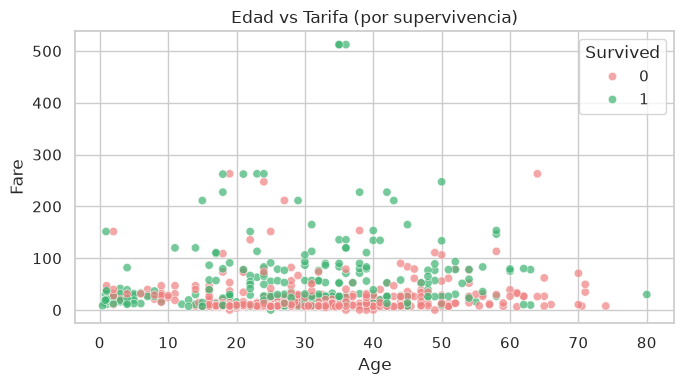

In [7]:
variables_numericas = datos.select_dtypes(include='number')

plt.figure(figsize=(7, 5))
sns.heatmap(variables_numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlacion numerica')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'correlacion.png'))
plt.show()

tabla_sexo = pd.crosstab(datos['Sex'], datos['Survived'], normalize='index') * 100
tabla_clase = pd.crosstab(datos['Pclass'], datos['Survived'], normalize='index') * 100

print('Supervivencia por Sexo (%):\n', tabla_sexo.round(1))
print('\nSupervivencia por Clase (%):\n', tabla_clase.round(1))

plt.figure(figsize=(12, 4))
ax1 = plt.subplot(1, 2, 1)
tabla_sexo.plot(kind='bar', ax=ax1, color=['lightcoral', 'mediumseagreen'])
plt.title('Supervivencia por Sexo')
plt.legend(['No sobrevivio', 'Sobrevivio'])

ax2 = plt.subplot(1, 2, 2)
tabla_clase.plot(kind='bar', ax=ax2, color=['lightcoral', 'mediumseagreen'])
plt.title('Supervivencia por Clase')
plt.legend(['No sobrevivio', 'Sobrevivio'])

plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'survived_sex_pclass.png'))
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x='Survived', y='Fare', data=datos, palette=['lightcoral', 'mediumseagreen'])
plt.title('Tarifa segun supervivencia')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'fare_por_survived.png'))
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(datos[datos['Survived'] == 0]['Age'].dropna(), kde=True, label='No sobrevivio', color='lightcoral', element='step')
sns.histplot(datos[datos['Survived'] == 1]['Age'].dropna(), kde=True, label='Sobrevivio', color='mediumseagreen', element='step')
plt.legend()
plt.title('Edad segun supervivencia')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'age_por_survived.png'))
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=datos, alpha=0.7, palette=['lightcoral', 'mediumseagreen'])
plt.title('Edad vs Tarifa (por supervivencia)')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'scatter_age_fare.png'))
plt.show()

## 7. Hipótesis iniciales (verificación con números)
- **H1:** las mujeres sobreviven más que los hombres.
- **H2:** la primera clase sobrevive más que la tercera.
- **H3:** los niños sobreviven más que los adultos.

In [8]:
tasa_mujeres = datos[datos['Sex'] == 'female']['Survived'].mean() * 100
tasa_hombres = datos[datos['Sex'] == 'male']['Survived'].mean() * 100

tasa_clase_1 = datos[datos['Pclass'] == 1]['Survived'].mean() * 100
tasa_clase_3 = datos[datos['Pclass'] == 3]['Survived'].mean() * 100

tasa_ninos = datos[datos['Age'] < 12]['Survived'].mean() * 100
tasa_adultos = datos[datos['Age'] >= 18]['Survived'].mean() * 100

print(f'Supervivencia mujeres: {tasa_mujeres:.1f}% | hombres: {tasa_hombres:.1f}%')
print(f'Supervivencia 1ra clase: {tasa_clase_1:.1f}% | 3ra clase: {tasa_clase_3:.1f}%')
print(f'Supervivencia niños (<12): {tasa_ninos:.1f}% | adultos (>=18): {tasa_adultos:.1f}%')

print('\n--- COMPROBACION ---')
print('H1:', 'ACEPTADA' if tasa_mujeres > tasa_hombres else 'RECHAZADA')
print('H2:', 'ACEPTADA' if tasa_clase_1 > tasa_clase_3 else 'RECHAZADA')
print('H3:', 'ACEPTADA' if tasa_ninos > tasa_adultos else 'RECHAZADA')

Supervivencia mujeres: 74.2% | hombres: 18.9%
Supervivencia 1ra clase: 63.0% | 3ra clase: 24.2%
Supervivencia niños (<12): 57.4% | adultos (>=18): 38.1%

--- COMPROBACION ---
H1: ACEPTADA
H2: ACEPTADA
H3: ACEPTADA


## 8. Insights
1. Solo el 38,4 % sobrevivió: el evento fue altamente mortal.
2. El sexo es el predictor más fuerte: las mujeres sobrevivieron ~74 % frente a ~19 % de los hombres.
3. La clase social importa: 1ra clase ~63 %, 2da ~47 %, 3ra ~24 %.
4. La tarifa pagada correlaciona con supervivencia (mediana mayor en sobrevivientes).
5. Los niños menores de 12 años sobrevivieron más que los adultos (prioridad de evacuación).
6. Calidad de datos: Age 19,9 % faltante, Cabin 77 % faltante, Embarked 2 casos faltantes.
7. Fare tiene sesgo positivo extremo: requiere transformación logarítmica.
8. Cabin es inutilizable como categórica; solo sirve como indicador de presencia (HasCabin).
9. Ticket y Name tienen alta cardinalidad: se excluyen del modelado directo.
10. Líneas futuras: imputación por grupos, encoding one-hot, escalado y PCA antes de clasificar.